# Prototipagem - Risco de Defasagem (Forecasting)

**Objetivo**: Validar a capacidade preditiva do modelo `RiskModel` (Random Forest) usando a arquitetura padronizada do projeto, com **Foco na Correção de Defasagem**.

**Configuração**:
- **Treino**: Dados de 2022 (Target: Risco em 2023)
- **Teste**: Dados de 2023 (Target: Risco em 2024)
- **Modelo**: Random Forest (Configuração Oficial)
- **Feature Engineering**: Aplicação automática da regra de correção de Defasagem (Idade x Fase Ideal).

Este notebook utiliza os módulos em `src/` para garantir consistência com o pipeline de produção.

In [15]:
import sys
import os
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

# Adicionar raiz do projeto ao PATH para importar src
project_root = Path(os.getcwd()).parent
sys.path.append(str(project_root))

# Imports do Projeto
from src.config import DATA_PATH, FEATURE_COLS, RANDOM_STATE
from src.data_loader import load_data
from src.feature_engineering import create_temporal_dataset, calculate_corrected_defasagem
from src.preprocessing import TemporalPreprocessor
from src.modeling import RiskModel
from src.evaluation import evaluate_model, print_reliability_report

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

## 1. Carregamento e Preparação dos Dados

In [16]:
print(f"Carregando dados de: {DATA_PATH}")
if not DATA_PATH.exists():
    data_path_str = f"../{DATA_PATH.name}"
else:
    data_path_str = str(DATA_PATH)

data_dict = load_data(data_path_str)

Carregando dados de: C:\pos_MLET\prj-datathon\BASE DE DADOS PEDE 2024 - DATATHON.xlsx


In [17]:
print("Criando datasets temporais com CORREÇÃO AUTOMÁTICA de Defasagem...")
# O dataset criado já possui a coluna 'Defasagem' recalculada pela função calculate_corrected_defasagem
train_df = create_temporal_dataset(data_dict, 2022)
test_df = create_temporal_dataset(data_dict, 2023)

print(f"Treino (22->23): {train_df.shape}")
print(f"Teste (23->24): {test_df.shape}")

Criando datasets temporais com CORREÇÃO AUTOMÁTICA de Defasagem...
Treino (22->23): (600, 11)
Teste (23->24): (765, 12)


Distribuição da Defasagem Corrigida (Treino 2022):
count    600.000000
mean      -0.891667
std        0.817135
min       -4.000000
25%       -1.000000
50%       -1.000000
75%        0.000000
max        2.000000
Name: Defasagem, dtype: float64


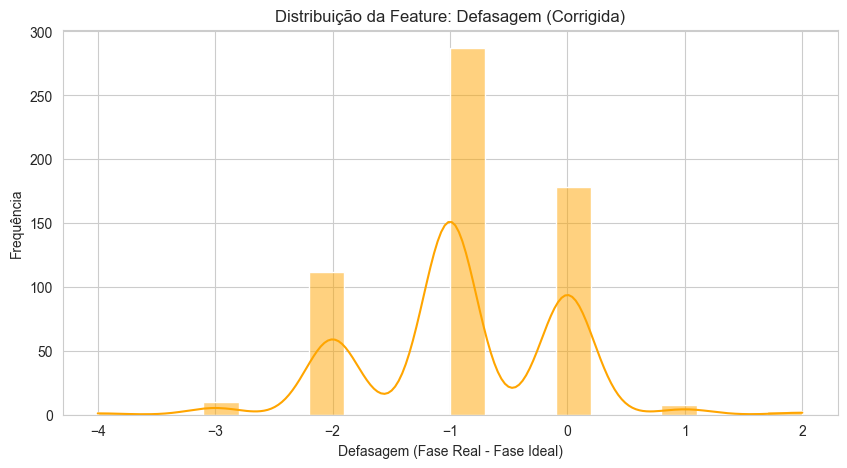

In [18]:
# Validação da Correção de Defasagem
# valores negativos indicam atraso
print("Distribuição da Defasagem Corrigida (Treino 2022):")
print(train_df['Defasagem'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(train_df['Defasagem'], kde=True, bins=20, color='orange')
plt.title('Distribuição da Feature: Defasagem (Corrigida)')
plt.xlabel('Defasagem (Fase Real - Fase Ideal)')
plt.ylabel('Frequência')
plt.show()

## 2. Modelagem (Pipeline Oficial)

In [19]:
# Seleção de Features
train_cols = [c for c in FEATURE_COLS if c in train_df.columns]
X_train = train_df[train_cols]
y_train = train_df['Target_Risk']

X_test = test_df[train_cols]
y_test = test_df['Target_Risk']

print(f"Features usadas: {train_cols}")

# Construção do Pipeline (Igual ao Produção)
pipeline = Pipeline([
    ('preprocessor', TemporalPreprocessor(feature_cols=train_cols)),
    ('clf', RandomForestClassifier(
        n_estimators=200, 
        max_depth=5, 
        class_weight='balanced', 
        random_state=RANDOM_STATE
    ))
])

model = RiskModel(model=pipeline)
model.train(X_train, y_train)
print("Modelo treinado com sucesso usando dados corrigidos.")

Features usadas: ['IAA', 'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'INDE', 'Defasagem']
Modelo treinado com sucesso usando dados corrigidos.


## 3. Avaliação e Confiabilidade

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

# O relatório foca no Recall (Sensibilidade) como métrica de segurança educacional.
metrics = evaluate_model(y_test, y_pred, y_prob)
print_reliability_report(metrics)


--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.76      0.55      0.64       393
           1       0.63      0.81      0.71       372

    accuracy                           0.68       765
   macro avg       0.70      0.68      0.68       765
weighted avg       0.70      0.68      0.67       765

ROC AUC: 0.7547
Precision (Risk): 0.6331
Recall (Risk): 0.8118

[Relatório de Confiabilidade do Modelo SAPE]
Métrica Principal de Decisão: Recall (Sensibilidade) da Classe de Risco: 81.18%

Justificativa para Produção:
No contexto educacional, o custo social de um 'Falso Negativo' (não identificar um aluno em risco real) é infinitamente superior ao custo de um 'Falso Positivo' (alertar preventivamente um aluno que conseguiria passar sozinho).

Por isso, o modelo foi otimizado para atuar como uma 'Rede de Segurança de Alta Sensibilidade':
1. Alta Cobertura (Recall 81%): De cada 10 alunos que realmente entrarão em defasagem, o modelo identif


=== [Ranking] Importância das Features (Peso no Modelo) ===
  Feature  Importance
      IPV    0.201543
Defasagem    0.200827
     INDE    0.162746
      IEG    0.106380
      IAN    0.099869
      IDA    0.094777
      IAA    0.071974
      IPS    0.061885


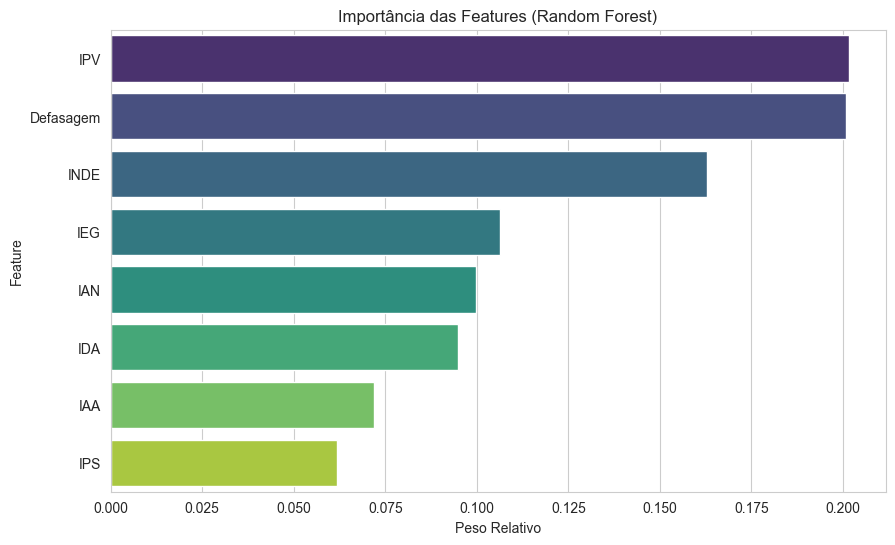

In [21]:
# Feature Importance
# Exibe a importância de cada variável no modelo preditivo.
if hasattr(model.model.named_steps['clf'], 'feature_importances_'):
    importances = model.model.named_steps['clf'].feature_importances_
    imp_df = pd.DataFrame({'Feature': train_cols, 'Importance': importances}).sort_values('Importance', ascending=False)
    
    print("\n=== [Ranking] Importância das Features (Peso no Modelo) ===")
    print(imp_df.to_string(index=False))
    
    plt.figure(figsize=(10, 6))
    # Corrigido para evitar DeprecationWarning do Seaborn
    sns.barplot(x='Importance', y='Feature', data=imp_df, hue='Feature', legend=False, palette='viridis')
    plt.title('Importância das Features (Random Forest)')
    plt.xlabel('Peso Relativo')
    plt.show()